## Customer Churn Analysis for a Fintech Bank

### 🧠 Business Problem
The bank is experiencing customer churn, leading to revenue loss and increased acquisition costs.

### 🎯 Objective
- Identify customers who are churning
- Understanding the key drivers of churn
- Provide actionable recommendations to improve retention

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

#Load Data
df = pd.read_csv('../data/raw/bank_churn.csv')

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 🔍 Data Overview

In [3]:

df.info()
df.describe()
df.isnull().sum()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 1.0 MB


(10000, 12)

### 🧠 Initial Observations
- The dataset consists of 10,000 entries.
- The data is predominantly numerical numerical (10 columns), with only 2 categorical features.
- There are no missing values across all columns, which eliminates the need for data imputation or cleaning related to null entries.

### 🧹 Data Cleaning

In [4]:
#Drop duplicates if any
df = df.drop_duplicates()

df.shape

(10000, 12)


- Dataset is clean and ready for analysis

### 📊 KPI Overview

In [5]:
churn_rate = df['churn'].mean() * 100
retention_rate = 100 - churn_rate

print(f"Churn Rate: {churn_rate:.2f}%")
print(f"Retention Rate: {retention_rate:.2f}%")

Churn Rate: 20.37%
Retention Rate: 79.63%


### Insight
- The bank is losing approximately 20.37% of customers, which indicates a significant retention issue.

### Demographic Analysis

##### 📊 Churn by Age

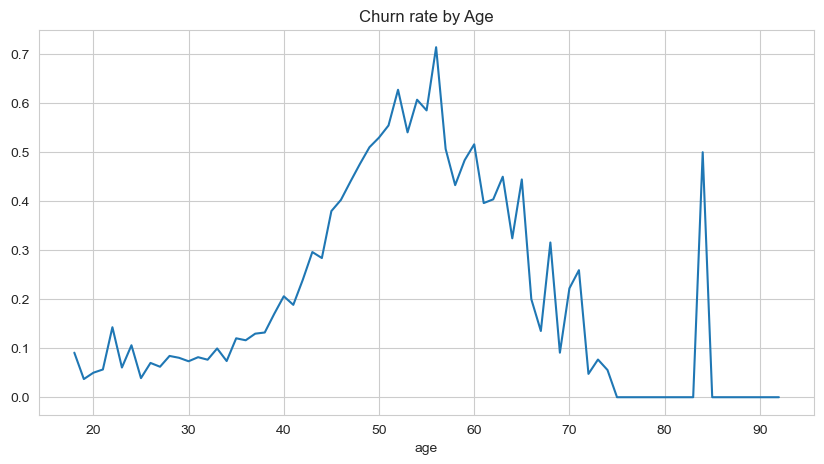

In [6]:
df.groupby('age')['churn'].mean().plot(figsize=(10,5))
plt.title("Churn rate by Age")
plt.show()

##### 📊 Churn by Gender

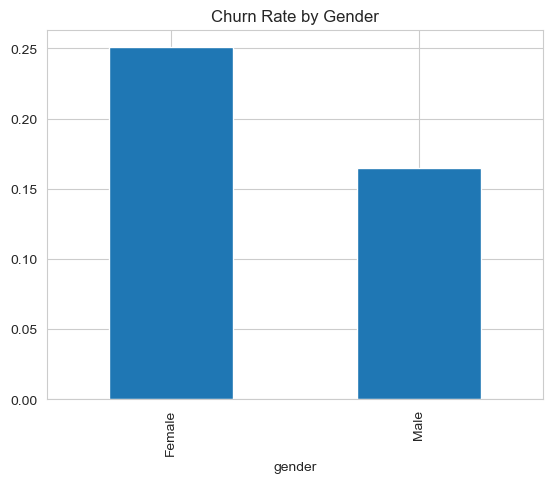

In [19]:
df.groupby('gender')['churn'].mean().plot(kind='bar')
plt.title("Churn Rate by Gender")
plt.show()

##### 📊 Churn by Geography

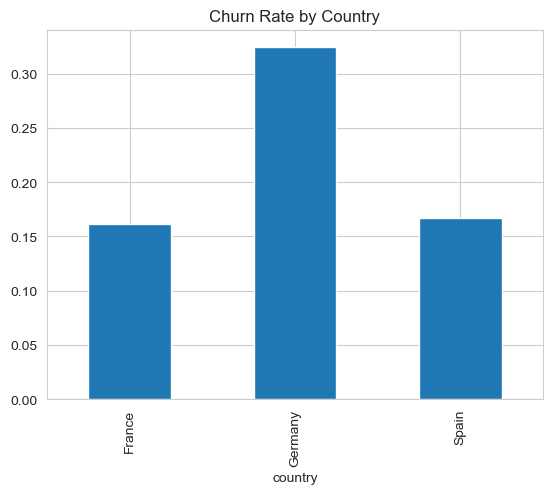

In [12]:
df.groupby('country')['churn'].mean().plot(kind='bar')
plt.title("Churn Rate by Country")
plt.show()

### Financial Analysis

##### 📊 Churn by Balance

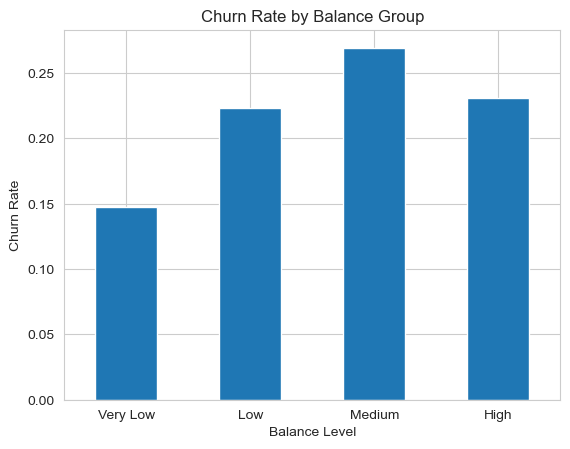

In [9]:

labels = ['Very Low', 'Low', 'Medium', 'High']
df['BalanceGroup'] = pd.qcut(df['balance'], 5, labels=labels, duplicates='drop')

df.groupby('BalanceGroup')['churn'].mean().plot(kind='bar')

plt.title("Churn Rate by Balance Group")
plt.xlabel("Balance Level")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

### Behavioral Analysis

📊 Active vs Inactive

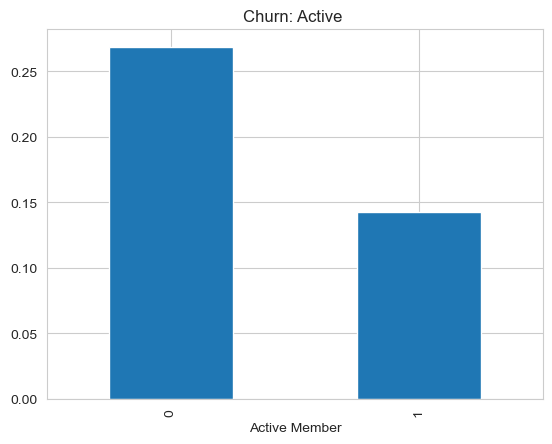

In [15]:
df.groupby('active_member')['churn'].mean().plot(kind="bar")
plt.title("Churn: Active ")
plt.xlabel("Active Member")
plt.show()

### Revenue at Risk

In [24]:
revenue_at_risk = df[df['churn'] == 1]['balance'].sum()
print(f"Revenue at Risk: {revenue_at_risk:,.2f}")

Revenue at Risk: 185,588,094.63


###### A Significant portion of customer balance is at risk due to churn.

### Key Findings

- Inactive customers are significantly more likey to churn
- High-balance customers represent the biggest revenue risk